In [27]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
%pip install lmfit
import lmfit

Note: you may need to restart the kernel to use updated packages.


Let's start by defining the necessary physical constants.

In [28]:
h = 6.626E-34 # kgm^2/s  (Planck's Constant)
m = 9.11E-31 # kg  (mass of an electron)
c = 3.00E8 # m/s (speed of light)

The first prompt is for the number of dye molecules.

Then, for each molecule, enter the value of $\lambda_\text{max}$ in nm and the number of bonds in the conjugated chain. For testing, you can use the sample data (Moog, 1991) in the code cell.

The output includes the length of the box, $L$, corresponding to that wavelength based on the equation

$$\lambda_\text{max} = {{8mcL^2}\over{h(N+1)}}$$

where $N$ is the number of π-electrons in the chain. Note that the various analyses may use number of electrons, number of bonds, or number of carbon atoms in the chain, but all of those are simply related to each other as shown in the code cell.


In [37]:
# Replace the following arrays with student data
wavelengths = np.array([592, 708, 813, 929])
electrons = np.array([10, 12, 14, 16])

# Uncomment the following lines to allow student input of data
# nmolecules = input("Enter the number of molecules: ")
# wavelengthlist = []
# electronlist = []
# for i in range(int(nmolecules)):
#     wavelengthlist.append(float(input("Enter the wavelength (nm) of molecule " + str(i+1) + ": ")))
#     electronlist.append(float(input("Enter the number of π-electrons in molecule " + str(i+1) + ": ")))
# wavelengths = np.array(wavelengthlist)
# electrons = np.array(electronlist)
wavelengthnm = wavelengths * 1.e-9
bonds = electrons - 2
carbons = electrons - 3
boxlength = np.sqrt(h * wavelengthnm * (electrons + 1) /(8 * m * c))
DE = h * c / wavelengthnm
df = pd.DataFrame({'wavelength (nm)': wavelengths, 'bonds': bonds, 'electrons': electrons, 'carbons': carbons, 'box length (m)': boxlength,
                   '∆E (J)': DE})
pd.set_option('display.precision', 2)
display(df)


,wavelength (nm),bonds,electrons,carbons,box length (m),∆E (J)
0,592,8,10,7,1.40e-09,3.36e-19
1,708,10,12,9,1.67e-09,2.81e-19
2,813,12,14,11,1.92e-09,2.45e-19
3,929,14,16,13,2.19e-09,2.14e-19


The following cells calculate the fit from Moog, *J. Chem. Educ.*, 1991. The two parameter fit is for the average bondlength in the conjugated chain and a paramter, $\gamma$ that represents the additional length due to the polarizability at the ends of the chain.

$$L = (b \times l) + \gamma$$

where $b$ and $L$ are the calculated box length and number of bonds for each dye, $l$ is the average bondlength, and $\gamma$ is the additional length.

In [30]:
def fit_Moog(params, b, length):
    Lcalc = params['bondlength'] * b + params['gamma'] 
    resid = length - Lcalc
    return resid

In [31]:
params_Moog = lmfit.Parameters()
params_Moog.add('bondlength', value = 1.39e-10)
params_Moog.add('gamma', value = 0.5)

resultMoog = lmfit.minimize(fit_Moog, params_Moog, args=(bonds, boxlength))

print(lmfit.fit_report(resultMoog))
print()
print("The average bondlength is", f"{resultMoog.params.valuesdict()['bondlength']:.2e}", "m")
print("The value of γ is", f"{resultMoog.params.valuesdict()['gamma']:.2e}", "m")

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 10
    # data points      = 4
    # variables        = 2
    chi-square         = 3.3765e-23
    reduced chi-square = 1.6883e-23
    Akaike info crit   = -208.515605
    Bayesian info crit = -209.743016
[[Variables]]
    bondlength:  1.3005e-10 +/- 9.1877e-13 (0.71%) (init = 1.39e-10)
    gamma:       3.6569e-10 +/- 1.0313e-11 (2.82%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(bondlength, gamma) = -0.9800

The average bondlength is 1.30e-10 m
The value of γ is 3.66e-10 m


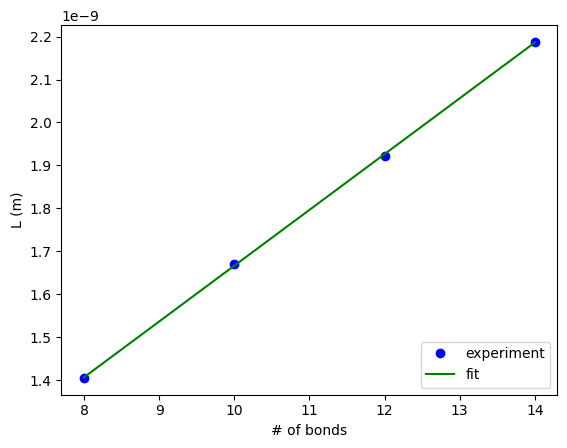

In [32]:
# check fit with plot

bondlength = resultMoog.params.valuesdict()['bondlength']
gamma = resultMoog.params.valuesdict()['gamma']
Lfit = bondlength * bonds + gamma
# plot fit

plt.plot(bonds, boxlength, marker='o', linestyle='', color='b')    # original data
plt.plot(bonds, Lfit,  marker='', linestyle='-', color='g')                # fit results
plt.xlabel("# of bonds")
plt.ylabel("L (m)")
plt.legend(['experiment', 'fit'], loc='lower right')

Shoemaker and Garland propose a fit based on Kuhn's original work on these conjugated dye systems. That fit also has two parameters: the bondlength $l$, and a parameter $\alpha$ that represents the fractional number of additional heavy atoms in the conjugated chain to represent the polarizability. The equation for this fit is

$$\lambda_\text{max} = {{8mcl^2}\over{h}} {{(p + 3 +\alpha)^2}\over{p+4}}$$

where $p$ is the number of carbon atoms in the conjugated chain.

In [33]:
def fit_Kuhn(params, p, length):
    lambdacalc = 8 * m * c * params['bondlength']**2 * (p + 3 + params['alpha'])**2 / (h * (p + 4))
    resid = length - lambdacalc
    return resid

In [34]:
params_Kuhn = lmfit.Parameters()
params_Kuhn.add('bondlength', value = 1.39e-10)
params_Kuhn.add('alpha', value = 1)

resultKuhn = lmfit.minimize(fit_Kuhn, params_Kuhn, args=(carbons, wavelengthnm))

print(lmfit.fit_report(resultKuhn))
print()
print("The average bondlength is", f"{resultKuhn.params.valuesdict()['bondlength']:.2e}", "m")
print("The value of α is", f"{resultKuhn.params.valuesdict()['alpha']:.2f}")

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 4
    # variables        = 2
    chi-square         = 2.4206e-17
    reduced chi-square = 1.2103e-17
    Akaike info crit   = -154.584943
    Bayesian info crit = -155.812354
[[Variables]]
    bondlength:  1.3005e-10 +/- 9.1925e-13 (0.71%) (init = 1.39e-10)
    alpha:       0.81196102 +/- 0.09896935 (12.19%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(bondlength, alpha) = -0.9872

The average bondlength is 1.30e-10 m
The value of α is 0.81


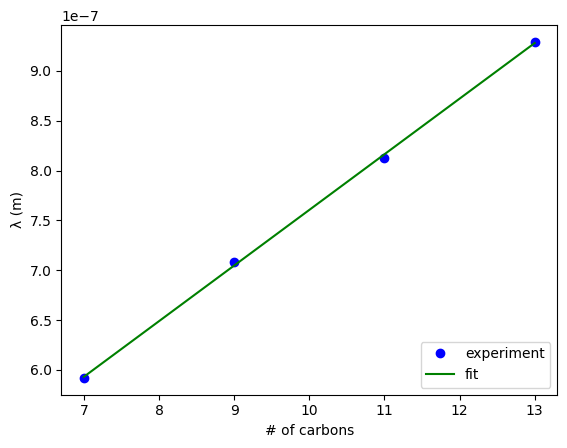

In [35]:
# check fit with plot

bondlength = resultKuhn.params.valuesdict()['bondlength']
alpha = resultKuhn.params.valuesdict()['alpha']
lambdaFit = 8 * m * c * bondlength**2 * (carbons + 3 + alpha)**2 / (h * (carbons + 4))
# plot fit

plt.plot(carbons, wavelengthnm, marker='o', linestyle='', color='b')    # original data
plt.plot(carbons, lambdaFit,  marker='', linestyle='-', color='g')      # fit results
plt.xlabel("# of carbons")
plt.ylabel("λ (m)")
plt.legend(['experiment', 'fit'], loc='lower right')

In [36]:
from scipy.optimize import root, fsolve
V0 = 10.0/ 27.211
L = 1.0 / 0.052917721092
def finitewellsym(x):
    return np.sqrt((V0 - x)/x) - np.tan(L/2 * np.sqrt(2 * x)) 

def finitewellasym(x):
    return np.sqrt((V0 - x)/x) + 1/np.tan(L/2 * np.sqrt(2 * x))


# result = finitewell(V0, L, 0.010975)
# print (V0, L)
# print (result)

# res = root(finitewell, 0.0109, args=(V0, L))
# print (res)

ressym = [fsolve(finitewellsym, x) for x in np.arange(0.01, V0, 0.01)]
print (ressym)

resasym = [fsolve(finitewellasym, x) for x in np.arange(0.01, V0, 0.01)]
print (resasym)

# crange = range(1, 11)

# res = [root(finitewell, 0.5, args=(V0, L, ci)).x[0] for ci in crange]

[array([0.01093668]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.09745449]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.26255864]), array([0.36610055]), array([0.36])]
[array([0.04359452]), array([0.04359452]), array([0.04359452]), array([0.04359452]), array([0.04359452]), array([0.17136424]), array([0.17136424]), array([0.17136424]), array([0.17136424]), array([0.17136424]), array([0.17136424]), array([0.17136424

/var/folders/8b/nw1y_50j6lv8zjrhxd6xlsch0000gp/T/ipykernel_34176/4110617439.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((V0 - x)/x) - np.tan(L/2 * np.sqrt(2 * x))
/var/folders/8b/nw1y_50j6lv8zjrhxd6xlsch0000gp/T/ipykernel_34176/4110617439.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  ressym = [fsolve(finitewellsym, x) for x in np.arange(0.01, V0, 0.01)]
